In [97]:
import sys
sys.path.append('..')

import os
from sqlalchemy import create_engine, text
import geopandas as gpd
import pandas as pd

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

In [98]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

In [99]:
def get_catastro():
    engine = obtener_engine()
    try:
        query = f'''
            SELECT * FROM catastro_iag.catastro
        '''
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ Error al obtener la capa de catastro: {e}")
        return gpd.GeoDataFrame()
    return None

def actualizar_control_bio(lista_ids):
    if not lista_ids:
        print("⚠️ La lista de IDs está vacía. No se realizó ninguna actualización.")
        return

    engine = obtener_engine()
    
    # Usamos un bloque 'with' para asegurar que la conexión se cierre sola
    with engine.begin() as connection:
        try:
            # Construimos la consulta SQL usando parámetros para evitar inyecciones SQL
            # El parámetro 'ids' recibe una tupla con tus IDs
            query = text("""
                UPDATE catastro_iag.catastro 
                SET ctrl_bio = True 
                WHERE idd IN :ids
            """)
            # Ejecutamos pasando la lista como una tupla
            result = connection.execute(query, {"ids": tuple(lista_ids)})
            print(f"✅ Se actualizaron {result.rowcount} registros en la tabla.")
        except Exception as e:
            print(f"❌ Error al actualizar la tabla: {e}")

In [100]:
gdf_catrastro = get_catastro()

In [101]:
gdf_catrastro.columns

Index(['idd', 'geom', 'id', 'unidad_01', 'unidad_02', 'unidad_03', 'unidad_04',
       'unidad_05', 'variedad', 'soca', 'zona', 'textura', 'cultivo',
       'financia', 'fs', 'area', 'fc', 'codco', 'zafra', 'seguimient',
       'estado', 'fci', 'tipoc', 'lote_admin', 'delagado', 'iag', 'ctrl_bio'],
      dtype='object')

In [102]:
dict_propiedades = {
    30: "CAMPODULCE",
    259: "SANTA ANA DE PAILON",
    482: "TEXAS",
    480: "EL CANAL",
    2250: "COSORIOCITO",
    2307: "CAMBERRA",
    2238: "EL PARAISO",
    577: "SAN ANTONIO--IAG",
    299: "CITTCA",
    2257: "TODOS SANTOS--CITTCA",
    122: "LAS CHACRAS-- WENDE"
}

In [103]:
dict_campodulce = {
    30: "CAMPODULCE",
    259: "SANTA ANA DE PAILON",
    482: "TEXAS",
    480: "EL CANAL",
    2250: "COSORIOCITO",
    2307: "CAMBERRA",
    2238: "EL PARAISO"
}

In [104]:
# paramtros
# socas mas jovenes
soca = 4
# variedad con riesgo
variedades = ['RB2','RB4','RBB7726']
# lista de codigos de propiedades para liberacion 800m al rededor
lista_codigos_props = list(dict_propiedades)

In [105]:
# filtar caña habilitada para zafra actual
gdf_catastro_canha = gdf_catrastro[(gdf_catrastro['unidad_03'] > 0) & 
                                   ((gdf_catrastro['cultivo'] == 'canha') | (gdf_catrastro['cultivo'] == 'semilla')) & 
                                   (gdf_catrastro['zafra'] == 2026) & 
                                   (gdf_catrastro['soca'] <= 4)]
gdf_catastro_canha['area'].sum()

32361.06645695801

In [106]:
# crea un disolve de catastro agrupado por unidad_01, y no convertir unidad_01 en index
gdf_catastro_disuelto = gdf_catastro_canha.dissolve(by='unidad_01', as_index=False)

In [107]:
# seleccionar el disolve solo de las propiedades de la listra (propiedades al que se aplicara 800m)
select_buffer_props = gdf_catastro_disuelto[gdf_catastro_disuelto['unidad_01'].isin(lista_codigos_props)]

<Axes: >

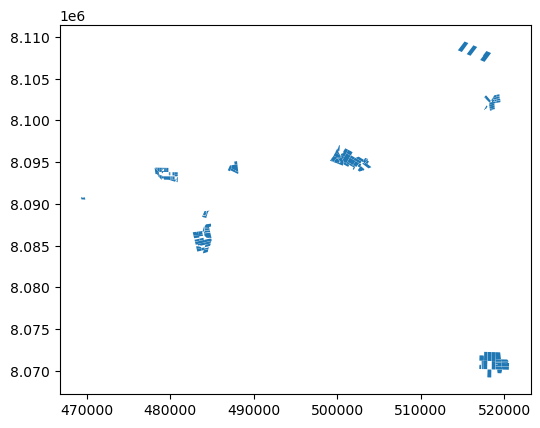

In [108]:
select_buffer_props.plot()

In [109]:
# copiar dataset de disolve de propiedaes y aplicar buffer de 800m
gdf_buffer = select_buffer_props[['unidad_01', 'geom']].copy()
gdf_buffer['geom'] = gdf_buffer.buffer(800)

In [110]:
# interseccion entree el buffer de las propiedades de interes y el catastro
gdf_interseccion = gpd.overlay(gdf_catastro_canha, gdf_buffer, how='intersection')

In [111]:
# crear lista de codigos de propiedades al rededor de las porpiedades de interes
lista_props_alrededor = list(set(gdf_interseccion['unidad_01_1']))
lista_props_alrededor = [int(i) for i in lista_props_alrededor]
print(lista_props_alrededor)

[2307, 260, 261, 519, 264, 9, 1545, 907, 12, 910, 1934, 1039, 1041, 18, 19, 404, 1682, 1686, 407, 279, 26, 797, 30, 1823, 421, 1706, 299, 941, 1454, 174, 2096, 951, 953, 699, 1852, 2238, 577, 325, 1479, 2250, 1100, 78, 79, 592, 2257, 218, 1115, 220, 1116, 2012, 482, 1009, 2035, 2295, 122, 123, 2046, 895]


<Axes: >

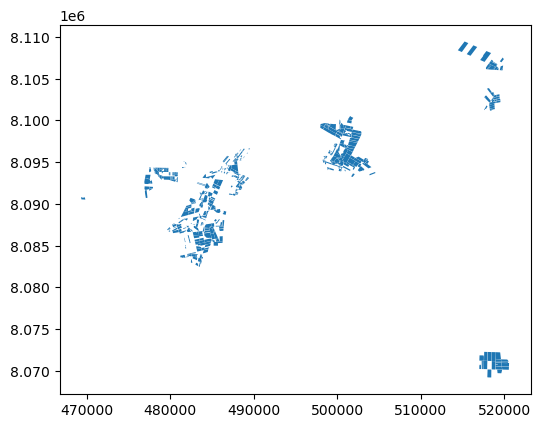

In [112]:
gdf_catastro_canha[gdf_catastro_canha['unidad_01'].isin(lista_props_alrededor)].plot()

In [113]:
# filtara cortes mas jovenes soca <= 3
gdf_catastro_canha = gdf_catastro_canha[
    (gdf_catastro_canha['soca'] <= soca) |
    (gdf_catastro_canha['variedad'].isin(variedades) & (gdf_catastro_canha['soca'] <= soca)) |
    (gdf_catastro_canha['unidad_01'].isin(lista_props_alrededor))
]

In [115]:
gdf_catastro_canha = gdf_catastro_canha[~gdf_catastro_canha['unidad_01'].isin(dict_campodulce)]

In [116]:
gdf_catastro_canha['area'].sum()

30856.84645695801

<Axes: >

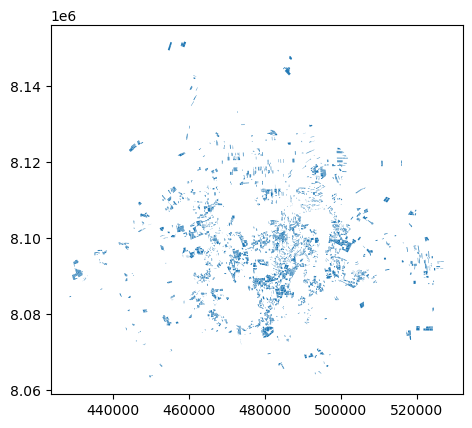

In [117]:
gdf_catastro_canha.plot()

In [59]:
gdf_catastro_canha['fc'] = gdf_catastro_canha['fc'].astype(str)
gdf_catastro_canha['fs'] = gdf_catastro_canha['fs'].astype(str)

In [60]:
#path = r"C:\Documents\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - EQUIPO AVIACION UTEA\Trichogramma\2026\ANALISIS DE AREA PARA RECOMENDACION\SHP\LOTES_RECOMENDACION.shp"

In [61]:
#gdf_catastro_canha.to_file(path, driver="ESRI Shapefile")

In [118]:
gdf_catastro_canha['area'].sum()

30856.84645695801

In [119]:
lista_de_idd = list(set(gdf_catastro_canha['idd']))
print('Cantidad de Idds:', len(lista_de_idd))

Cantidad de Idds: 5126


In [120]:
actualizar_control_bio(lista_de_idd)

✅ Se actualizaron 5126 registros en la tabla.
